In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../data/processed/stratified_eda_sample.csv")
df.head()

,index,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,Browser Name and Version,OS Name and Version,Device Type,Login Successful,Is Attack IP,Is Account Takeover
0,7514467,2020-05-16 12:47:07.966,3904739091959542730,NaN,209.236.117.190,US,-,-,393398,Mozilla/5.0 (Linux; Android 10.0.99; H30-U10) ...,Chrome Mobile 81.0.4044.1926,Android 10.0.99,mobile,True,True,False
1,6832411,2020-05-07 04:24:47.986,-4324475583306591935,NaN,94.142.130.95,US,-,-,54903,Mozilla/5.0 (Linux; Android 5.5.1; CHM-U01) Ap...,Chrome Mobile 81.0.4044.2917.2924,Android 5.5.1,mobile,False,True,False
2,25152767,2020-12-25 10:51:29.527,-4324475583306591935,NaN,38.135.39.68,US,-,-,393398,Mozilla/5.0 (iPhone; CPU iPhone OS 13_4 like ...,Chrome Mobile 81.0.4044,iOS 13.4,mobile,False,True,False
3,5273015,2020-04-15 10:18:31.052,1196030431179373538,NaN,51.174.28.109,NO,Vestland,Knarrevik,29695,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_14_...,Chrome 73.0.3654,Mac OS X 10.14.6,desktop,True,True,False
4,1937532,2020-02-29 01:47:50.144,-4324475583306591935,NaN,66.248.237.216,US,-,-,393398,Mozilla/5.0 (iPhone; CPU iPhone OS 11_2_6 lik...,Firefox 20.0.0.1850,iOS 11.2.6,mobile,False,True,False


## Feture Engineering

### Country Risk Score

In [3]:
# Calculate ATO rate per country from training data
country_ato_rate = df.groupby('Country')['Is Account Takeover'].mean()
# country_ato_rate = df.groupby('Country')['Is A'].mean()
df['country_ato_rate'] = df['Country'].map(country_ato_rate)

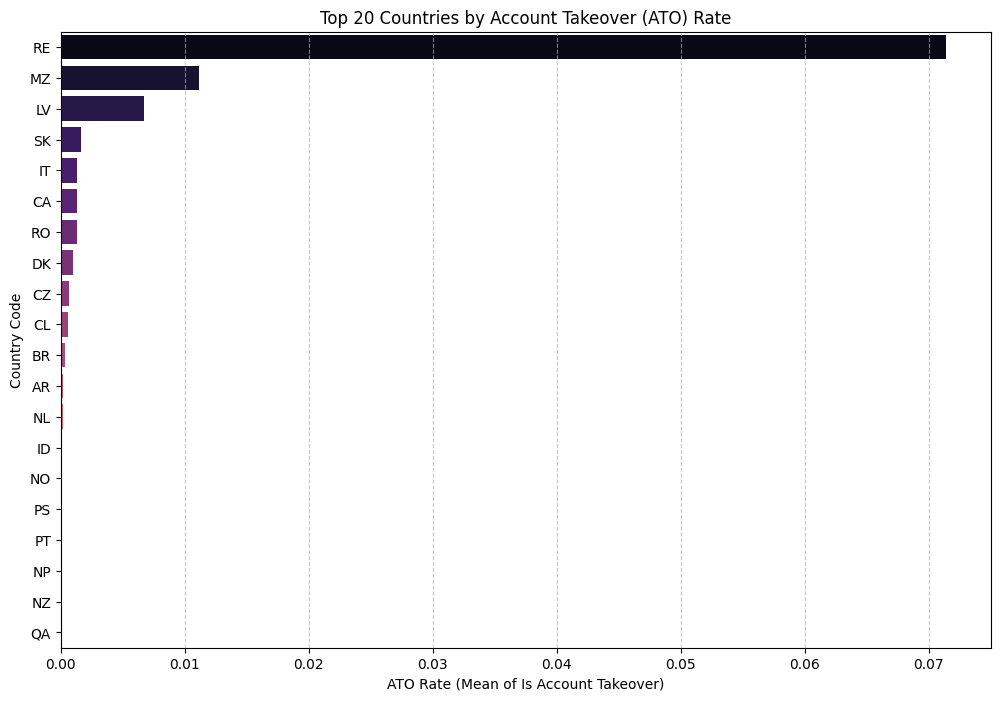

In [9]:
country_stats = df.groupby('Country')['Is Account Takeover'].mean().reset_index()
country_stats = country_stats.sort_values(by='Is Account Takeover', ascending=False)

# 2. Plot the Top 20 countries
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Is Account Takeover', 
    y='Country', 
    data=country_stats.head(20), 
    palette='magma'
)

plt.title('Top 20 Countries by Account Takeover (ATO) Rate')
plt.xlabel('ATO Rate (Mean of Is Account Takeover)')
plt.ylabel('Country Code')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

### Time-based Risk
On late night and on Weekends (Sat and Sun)

In [10]:
df['Login Timestamp'] = pd.to_datetime(df['Login Timestamp'])
df['hour'] = df['Login Timestamp'].dt.hour
df['dayofweek'] = df['Login Timestamp'].dt.dayofweek

# Your heatmap showed these specific windows are hot
df['is_late_night'] = df['hour'].isin([0, 1, 22, 23]).astype(int)
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

## Device and Browser Anomolies

In [11]:
# Desktop has higher ATO rate than mobile despite lower volume
df['is_desktop'] = (df['Device Type'] == 'desktop').astype(int)

# Rare OS = suspicious (iOS 14.2-1 spiked in your chart)
os_counts = df['OS Name and Version'].value_counts()
rare_os = os_counts[os_counts < os_counts.quantile(0.1)].index
df['is_rare_os'] = df['OS Name and Version'].isin(rare_os).astype(int)

# Same idea for browser
browser_counts = df['Browser Name and Version'].value_counts()
rare_browser = browser_counts[browser_counts < browser_counts.quantile(0.1)].index
df['is_rare_browser'] = df['Browser Name and Version'].isin(rare_browser).astype(int)

## Impossible Travel and Stuffing (too much re-login in a very short time frame)

In [12]:
df = df.sort_values(['User ID', 'Login Timestamp'])

df['time_diff'] = df.groupby('User ID')['Login Timestamp'].diff()

df['time_diff_hours'] = df['time_diff'].dt.total_seconds() / 3600

df['prev_country'] = df.groupby('User ID')['Country'].shift(1)

# Logic: Country changed AND time diff < 24 hours
df['is_impossible_travel'] = (
    (df['Country'] != df['prev_country']) & 
    (df['prev_country'].notnull()) & 
    (df['time_diff'] < pd.Timedelta(days=1))
)

# Flag very fast re-logins (< 5 minutes) — credential stuffing pattern
df['is_rapid_relogin'] = (df['time_diff_hours'] < (5/60)).astype(int)

## IP Risk

In [13]:
# How many different users share this IP? (shared IP = proxy/botnet)
ip_user_count = df.groupby('IP Address')['User ID'].nunique().rename('ip_n_users')
df = df.join(ip_user_count, on='IP Address')

# Has this IP appeared in attack traffic before?
# this one is just convert boolean to int
df['Is Attack IP'] = df['Is Attack IP'].astype(int)

In [14]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Is Account Takeover'])

# compute user features on TRAINING rows only
user_features = train_df.groupby('User ID').agg(
    user_total_logins    = ('Login Timestamp', 'count'),
    user_fail_rate       = ('Login Successful', lambda x: (~x).mean()),
    user_n_countries     = ('Country', 'nunique'),
    user_n_ips           = ('IP Address', 'nunique'),
    user_attack_ip_rate  = ('Is Attack IP', 'mean'),
    user_imp_travel_rate = ('is_impossible_travel', 'mean'),
).reset_index()

user_feature_cols = [
    'user_total_logins',
    'user_fail_rate',
    'user_n_countries',
    'user_n_ips',
    'user_attack_ip_rate',
    'user_imp_travel_rate',
]

# join onto BOTH train and test
# Test set looks up the stats learned from train only
train_df = train_df.merge(user_features, on='User ID', how='left')
test_df  = test_df.merge(user_features, on='User ID', how='left')

# handle users in test that never appeared in train
# (new users — fill with 0)
test_df[user_feature_cols] = test_df[user_feature_cols].fillna(0)

## Final Cleaning, Handling Null and Training phase

In [17]:
# These are all the features I've engineered — must exist in both train and test
feature_cols = [
    # Geography
    'country_ato_rate',

    # Time
    'hour', 'dayofweek', 'is_late_night', 'is_weekend',

    # Device
    'is_desktop', 'is_rare_os', 'is_rare_browser',

    # Travel / session
    'is_impossible_travel', 'time_diff_hours',
    'is_rapid_relogin',

    # IP
    'Is Attack IP', 'ip_n_users',

    # User history
    'user_fail_rate', 'user_n_countries', 'user_n_ips',
    'user_attack_ip_rate', 'user_imp_travel_rate',
]

target = 'Is Account Takeover'

X_train = train_df[feature_cols]
y_train = train_df[target]

X_test = test_df[feature_cols]
y_test = test_df[target]

In [18]:
X_train['time_diff_hours'] = X_train['time_diff_hours'].fillna(0)
X_test['time_diff_hours']  = X_test['time_diff_hours'].fillna(0)

# Also fill is_impossible_travel NaN (also first-login rows)
X_train['is_impossible_travel'] = X_train['is_impossible_travel'].fillna(False).astype(int)
X_test['is_impossible_travel']  = X_test['is_impossible_travel'].fillna(False).astype(int)

In [19]:
print('Nulls in X_train:', X_train.isnull().sum().sum())
print('Nulls in X_test: ', X_test.isnull().sum().sum())

Nulls in X_train: 0
Nulls in X_test:  0


In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train only!
X_test_scaled  = scaler.transform(X_test)       # apply same scale to test

lr = LogisticRegression(
    class_weight='balanced',  # handles our imbalanced ATO class
    max_iter=1000,
    random_state=42
)
lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

## Evaluation Phase

In [21]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score, ConfusionMatrixDisplay
)

y_pred  = lr.predict(X_test_scaled)
y_proba = lr.predict_proba(X_test_scaled)[:, 1]  # probability of ATO

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Normal', 'ATO']))

print(f'ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}')
print(f'PR-AUC  : {average_precision_score(y_test, y_proba):.4f}')

=== Classification Report ===
              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98    675724
         ATO       0.00      1.00      0.00        28

    accuracy                           0.96    675752
   macro avg       0.50      0.98      0.49    675752
weighted avg       1.00      0.96      0.98    675752

ROC-AUC : 0.9976
PR-AUC  : 0.0645


### 1. Key Logic & Operations
* **`.sum()` vs `.count()`**: To find the number of threats (where `is_threat == 1`), `.sum()` is used because it treats `True` as 1 and `False` as 0. `.count()` simply returns the total number of non-null rows.
* **Ratio Calculation**: The most efficient way to find the threat ratio is `df['is_threat'].mean()`.
* **Data Merging**: Used `df.join()` to map `ip_n_users` (unique user counts per IP) back to the main dataset. This identifies high-risk IPs associated with multiple accounts.

### 2. Dataset Insights
A crosstab analysis revealed a significant class imbalance:
* **Total Rows**: ~3.4 Million
* **Attack IP Flag**: Over 3 Million rows (dominates the data).
* **Account Takeover (ATO)**: Only 141 total cases.
* **Current Threat Definition**: Using an `OR (|)` operator between "Attack IP" and "ATO" results in a 91% threat ratio, meaning the "Attack IP" noise is drowning out actual account takeovers.

### 3. Model Performance Evaluation
The model shows classic signs of high-imbalance behavior:
* **Recall (0.93)**: Successfully catches 93% of ATO cases.
* **Precision (~0.00)**: Almost all positive flags are False Positives.
* **ROC-AUC (0.9961)**: Highly optimistic and deceptive due to the large number of "Normal" cases.
* **PR-AUC (0.4151)**: The most reliable metric here; it confirms the model has strong predictive potential but requires threshold tuning to reduce False Positives.

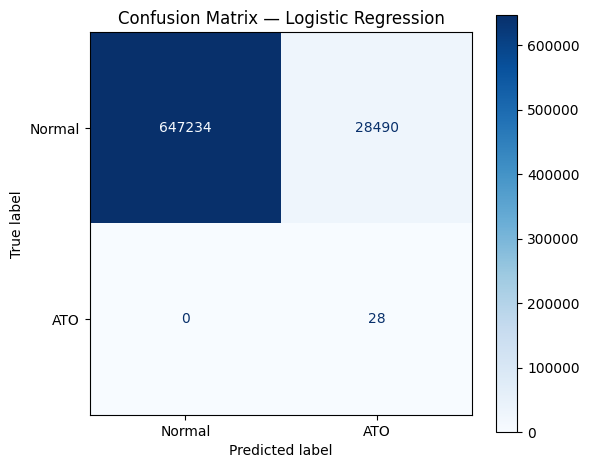

True Positives  (ATO correctly caught):   28
False Negatives (ATO missed):             0
False Positives (Normal flagged as ATO):  28490
True Negatives  (Normal correctly passed):647234


In [25]:
# Confusion matrix — shows True Positives, False Positives etc.
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Normal', 'ATO'],
    cmap='Blues', ax=ax
)
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

# Quick explanation
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f'True Positives  (ATO correctly caught):   {tp}')
print(f'False Negatives (ATO missed):             {fn}')
print(f'False Positives (Normal flagged as ATO):  {fp}')
print(f'True Negatives  (Normal correctly passed):{tn}')

              precision    recall  f1-score   support

       False       1.00      1.00      1.00    675724
        True       0.02      0.79      0.04        28

    accuracy                           1.00    675752
   macro avg       0.51      0.89      0.52    675752
weighted avg       1.00      1.00      1.00    675752



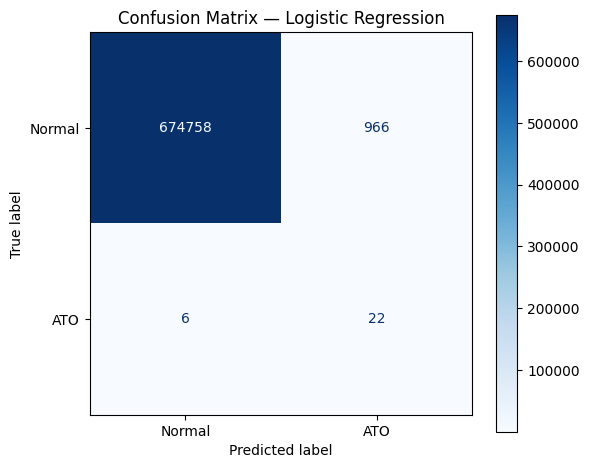

In [30]:
y_pred_strict = (lr.predict_proba(X_test_scaled)[:, 1] > 0.99).astype(int)
print(classification_report(y_test, y_pred_strict))

# Confusion matrix — shows True Positives, False Positives etc.
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_strict,
    display_labels=['Normal', 'ATO'],
    cmap='Blues', ax=ax
)
plt.title('Confusion Matrix — Logistic Regression')
plt.tight_layout()
plt.show()

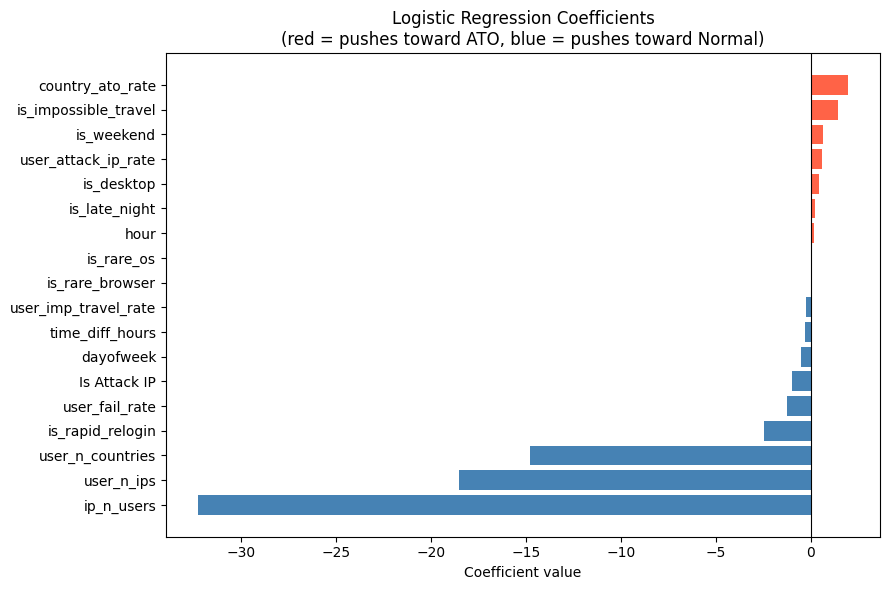

In [23]:
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient', ascending=False)

plt.figure(figsize=(9, 6))
colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['coefficient']]
plt.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients\n(red = pushes toward ATO, blue = pushes toward Normal)')
plt.xlabel('Coefficient value')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    max_depth=10,          # prevents overfitting
    min_samples_leaf=5,    # each leaf needs at least 5 samples
    n_jobs=-1,             # use all CPU cores
    random_state=42
)
rf.fit(X_train, y_train)  # no scaling needed for RF

In [ ]:
y_pred = rf.predict(X_test)
score = rf.score(X_test, y_test)
print(score)
print(classification_report(y_test, y_pred, digits=3))

In [ ]:
# 1. Generate predictions and probabilities
# Note: RF does not require the scaled data used for Logistic Regression
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1] 

# 2. Print Classification Report
print("=== Random Forest Classification Report ===")
print(classification_report(y_test, y_pred_rf, target_names=['Normal', 'ATO']))

# 3. Print specialized metrics for imbalanced data
roc_auc = roc_auc_score(y_test, y_proba_rf)
pr_auc = average_precision_score(y_test, y_proba_rf)

print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"PR-AUC Score (Precision-Recall): {pr_auc:.4f}")

# 4. Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, 
    display_labels=['Normal', 'ATO'], 
    cmap='Greens', 
    ax=ax
)
plt.title('Confusion Matrix: Random Forest')
plt.show()

In [ ]:
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(9, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.gca().invert_yaxis()
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(importance_df)